# Task 2 - Single-Video Newscast Analysis

**Chosen video:** `Telejornal_RTP_Jan_13_2026` (the last RTP broadcast in our corpus, broadcast 5 days before the Portuguese presidential election of Jan 18, 2026).

**Goals from the project description:**

> a) Try to identify when the scene moves from the anchor to the different news.
>
> b) Try to identify different topics across the news, count the number of different news, and their length.

**Bonus:** Is one modality enough to characterize the videos?

## Approach

We do not have visual feature files (`*_visual.pkl`) for the newscasts. What we have is:

- `Telejornal_RTP_Jan_13_ocr.pkl` - one row per sampled frame (1 fps), with a list of detected text boxes (`bbox`, `text`, `conf`).
- `Telejornal_RTP_Jan_13_speech.pkl` - one row per Whisper-diarized segment with `timestamp`, `duration`, `transcript`, and a 4096-d EuroLLM embedding.

RTP overlays a persistent topic chyron in the lower third of every news frame (e.g. `ELEICOES PRESIDENCIAIS`, `PACOTE LABORAL`). The chyron changes when the story changes and disappears during anchor shots and transitions. This gives a strong signal for both goals:

| goal | signal |
|------|--------|
| (a) anchor vs news | presence/absence of chyron per frame |
| (b) topic count + length | contiguous runs of frames sharing the same chyron |

We then validate the OCR-derived segmentation against the speech embeddings.

## Notebook layout

- Section 0 - Setup
- Section 1 - Load OCR and speech data
- Section 2 - Parse OCR frames
- Section 3 - Goal (a): anchor vs news segmentation
- Section 4 - Goal (b): topic count, length, and thematic grouping
- Section 5 - Cross-modal validation
- Section 6 - Save artifacts and summary

## Section 0 - Setup

In [1]:
%matplotlib inline

import os
import re
import sys
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

SEED = 42
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
TABLES_DIR = ARTIFACTS_DIR / "tables"
for d in (ARTIFACTS_DIR, FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

VIDEO_ID = "Telejornal_RTP_Jan_13"
print(f"python  : {sys.version.split()[0]}")
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"video   : {VIDEO_ID}")

python  : 3.12.12
numpy   : 2.4.4
pandas  : 3.0.2
video   : Telejornal_RTP_Jan_13


## Section 1 - Load the chosen video

We load two pickles for this broadcast:

1. `*_ocr.pkl` - one row per sampled frame. Column `Frame` is a path string `Frames/<video>/frame_<N>.jpg` and `OCR` is a list of `{bbox, text, conf}` dicts. Sampling is 1 fps so the integer `N` equals the broadcast second.
2. `*_speech.pkl` - one row per Whisper segment with `timestamp`, `duration`, `transcript`, and `text_embedding` (4096-d float32).

Both share the same timeline anchored at `t=0`, so we can join stories to speech segments by interval overlap.

In [2]:
ocr_path = DATA_DIR / f"{VIDEO_ID}_ocr.pkl"
ocr_raw = pd.read_pickle(ocr_path)
print(f"OCR file : {ocr_path}")
print(f"  rows   : {len(ocr_raw):,}")
print(f"  cols   : {list(ocr_raw.columns)}")
ocr_raw.head(2)

OCR file : data/Telejornal_RTP_Jan_13_ocr.pkl
  rows   : 3,078
  cols   : ['Frame', 'OCR']


,Frame,OCR
0,Frames/Telejornal_RTP_Jan_13/frame_1956.jpg,"[{'bbox': [997.0, 36.0, 1088.0, 64.0], 'text':..."
1,Frames/Telejornal_RTP_Jan_13/frame_1908.jpg,"[{'bbox': [999.0, 38.0, 1086.0, 63.0], 'text':..."


In [3]:
speech_path = DATA_DIR / f"{VIDEO_ID}_speech.pkl"
speech = pd.read_pickle(speech_path).reset_index(drop=True)
print(f"speech file : {speech_path}")
print(f"  segments  : {len(speech)}")
print(f"  cols      : {list(speech.columns)}")
print(f"  t-range   : {speech['timestamp'].min():.1f}s - {(speech['timestamp']+speech['duration']).max():.1f}s")
print(f"  total spk : {speech['duration'].sum():.1f}s ({speech['duration'].sum()/60:.1f} min)")
speech.head(2)

speech file : data/Telejornal_RTP_Jan_13_speech.pkl
  segments  : 34
  cols      : ['timestamp', 'duration', 'transcript', 'text_embedding']
  t-range   : 90.5s - 3058.0s
  total spk : 1303.7s (21.7 min)


,timestamp,duration,transcript,text_embedding
0,90.481,47.723,"Bom, no item de aventura e antónios de seguro...","[1.8843144, -0.07956522, 0.0068191336, 0.14520..."
1,140.431,66.893,Nelha eção mais imprevisível dos últimos anos...,"[1.8258227, 0.021352299, -0.30258605, 0.026715..."


## Section 2 - Parse OCR frames

Each OCR row contains a list of text boxes covering the full frame. We focus on the RTP lower-third chyron region and extract a structured field per frame.

### Regions (RTP layout, 1280x720)

| field | rule |
|-------|------|
| `topic_headline` | bold or ALL-CAPS box with y-center in [530, 595] - the main news label |
| `topic_subline` | text in y in [595, 670] - the descriptive sentence under the headline |
| `clock` | `HH:MM` pattern in top-right (x > 1000, y < 200), extracted but returned 0 matches in this broadcast; RTP does not appear to display a visible on-screen clock during this edition |
| `location_tag` | bold short box in top-left (x < 600, y < 100) |

In [4]:
FRAME_RE = re.compile(r"frame_(\d+)\.jpg$")

def _parse_frame_idx(s):
    m = FRAME_RE.search(s)
    if not m:
        raise ValueError(f"unexpected frame path: {s}")
    return int(m.group(1))

ocr = ocr_raw.copy()
ocr["frame_idx"] = ocr["Frame"].map(_parse_frame_idx)
ocr = ocr.sort_values("frame_idx").reset_index(drop=True)

fmin, fmax = ocr["frame_idx"].min(), ocr["frame_idx"].max()
step_counts = Counter(ocr["frame_idx"].diff().dropna().astype(int).tolist())
print(f"frame range : {fmin}..{fmax}  (span {fmax-fmin+1}s = {(fmax-fmin+1)/60:.1f} min)")
print(f"rows        : {len(ocr):,}")
print(f"step counts : {dict(step_counts.most_common(5))}")
print(f"sampling    : {'uniform 1 fps' if step_counts.most_common(1)[0][0]==1 else 'NON-uniform'}")

frame range : 1..3078  (span 3078s = 51.3 min)
rows        : 3,078
step counts : {1: 3077}
sampling    : uniform 1 fps


### 2.2 - Text helpers and headline correction

Three text utilities used throughout the parser. We also correct known OCR fusion artifacts where two adjacent chyron lines were merged without a space (e.g. `SONDAGEM RTPPRESIDENCIAIS 2026` instead of `SONDAGEM PRESIDENCIAIS`). These were identified by inspecting the top-frequency headline list.

In [5]:
TAG_RE = re.compile(r"</?[a-zA-Z]+>")
WS_RE  = re.compile(r"\s+")

def strip_tags(s):
    return TAG_RE.sub("", s)

def has_bold(s):
    return "<b>" in s or "<mark>" in s

def normalize_text(s):
    s = unicodedata.normalize("NFKC", s)
    s = WS_RE.sub(" ", s).strip()
    return s.upper()

def bbox_center(b):
    x1, y1, x2, y2 = b
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0

# Corrections for OCR fusion artifacts (two adjacent chyron lines merged without a space).
# Identified by inspecting the top-frequency headline list.
HEADLINE_FIXES = {
    "SONDAGEM RTPPRESIDENCIAIS 2026":        "SONDAGEM PRESIDENCIAIS",
    "SEM DINHEIROPARA MEDICAMENTOS":         "SEM DINHEIRO PARA MEDICAMENTOS",
    "TENSÃO NO IRÃOAJUDA A CAMINHO":      "TENSÃO NO IRÃO",
    "TENSÃO NO IRÃOTRUMP PROMETE AJUDA":   "TENSÃO NO IRÃO",
    "PORTO X BENFICADUELO DA TAÇA":      "PORTO X BENFICA",
    "PORTO X BENFICAAMANHÃ NA RTP1":     "PORTO X BENFICA",
}

def fix_headline_fusion(s):
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return s
    return HEADLINE_FIXES.get(s, s)

print(strip_tags("<b>ANSIÃO</b>"), "|", has_bold("<b>x</b>"), "|", normalize_text("  Pacote   Laboral "))
print("fusion fix test:", fix_headline_fusion("SONDAGEM RTPPRESIDENCIAIS 2026"))
print("pass-through test:", fix_headline_fusion("SONDAGEM PRESIDENCIAIS"))

ANSIÃO | True | PACOTE LABORAL
fusion fix test: SONDAGEM PRESIDENCIAIS
pass-through test: SONDAGEM PRESIDENCIAIS


In [6]:
CLOCK_RE = re.compile(r'^\s*(\d{1,2})[:.:]\s*(\d{2})\s*$')
MAX_HEADLINE_CHARS = 40

def parse_frame(boxes, min_conf=0.5):
    out = {"n_boxes": len(boxes), "topic_headline": None,
           "topic_subline": None, "clock": None, "location_tag": None}
    best_head  = None
    best_sub   = None
    best_clock = None
    best_loc   = None

    for b in boxes:
        if b.get("conf", 0.0) < min_conf:
            continue
        raw  = b.get("text", "") or ""
        text = strip_tags(raw).strip()
        if not text:
            continue
        xc, yc = bbox_center(b["bbox"])
        x1, y1, x2, y2 = b["bbox"]
        width = x2 - x1

        if 530 <= yc <= 595:
            is_caps = sum(c.isalpha() for c in text) >= 3 and text == text.upper()
            if (has_bold(raw) or is_caps) and 3 <= len(text) <= MAX_HEADLINE_CHARS:
                if best_head is None or width > best_head[0]:
                    best_head = (width, text)

        if 595 <= yc <= 670:
            if len(text) >= 5 and sum(c.isalpha() for c in text) >= 3:
                if best_sub is None or width > best_sub[0]:
                    best_sub = (width, text)

        if xc > 1000 and yc < 200:
            m = CLOCK_RE.match(text)
            if m:
                if best_clock is None or xc > best_clock[0]:
                    best_clock = (xc, f"{int(m.group(1)):02d}:{m.group(2)}")

        if xc < 600 and yc < 100 and has_bold(raw):
            if best_loc is None or width > best_loc[0]:
                best_loc = (width, text)

    if best_head:  out["topic_headline"] = best_head[1]
    if best_sub:   out["topic_subline"]  = best_sub[1]
    if best_clock: out["clock"]          = best_clock[1]
    if best_loc:   out["location_tag"]   = best_loc[1]
    return out

for i in range(3):
    print(f"frame {ocr['frame_idx'].iloc[i]:4d}  ->  {parse_frame(ocr['OCR'].iloc[i])}")

frame    1  ->  {'n_boxes': 3, 'topic_headline': None, 'topic_subline': None, 'clock': None, 'location_tag': None}
frame    2  ->  {'n_boxes': 1, 'topic_headline': 'SONDAGEM RTPPRESIDENCIAIS 2026', 'topic_subline': None, 'clock': None, 'location_tag': None}
frame    3  ->  {'n_boxes': 3, 'topic_headline': 'SONDAGEM RTPPRESIDENCIAIS 2026', 'topic_subline': None, 'clock': None, 'location_tag': None}


### 2.3 - Build the frame-level dataframe

Apply `parse_frame` to every row, then normalize and correct the headline. The `headline_norm` column (NFKC + uppercase + collapsed whitespace + fusion fix) is what we group on in Section 3.

In [7]:
parsed = ocr["OCR"].map(parse_frame).apply(pd.Series)
frames_df = pd.concat([ocr[["frame_idx"]].rename(columns={"frame_idx": "t_sec"}), parsed], axis=1)

frames_df["headline_norm"] = frames_df["topic_headline"].map(
    lambda s: fix_headline_fusion(normalize_text(s)) if isinstance(s, str) else None
)
frames_df["has_chyron"] = frames_df["headline_norm"].notna()

print(f"frames parsed   : {len(frames_df):,}")
print(f"with headline   : {frames_df['has_chyron'].sum():,} ({frames_df['has_chyron'].mean()*100:.1f}%)")
print(f"with clock      : {frames_df['clock'].notna().sum():,}")
print(f"with location   : {frames_df['location_tag'].notna().sum():,}")
frames_df.head(10)

frames parsed   : 3,078
with headline   : 2,248 (73.0%)
with clock      : 0
with location   : 43


,t_sec,n_boxes,topic_headline,topic_subline,clock,location_tag,headline_norm,has_chyron
0,1,3.0,NaN,NaN,NaN,NaN,NaN,False
1,2,1.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
2,3,3.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
3,4,1.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
4,5,4.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
5,6,6.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
6,7,7.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
7,8,6.0,SONDAGEM RTP\nPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM RTP PRESIDENCIAIS 2026,True
8,9,6.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True
9,10,5.0,SONDAGEM RTPPRESIDENCIAIS 2026,NaN,NaN,NaN,SONDAGEM PRESIDENCIAIS,True


In [8]:
top_heads = frames_df["headline_norm"].value_counts().head(30)
print("Top 30 headlines by frame-count (seconds on screen):\n")
for h, c in top_heads.items():
    print(f"  {c:4d}s  {h}")

Top 30 headlines by frame-count (seconds on screen):

   434s  SONDAGEM PRESIDENCIAIS
   178s  PRESIDENCIAIS 2026
   175s  MARIA CASTELLO BRANCO
   143s  MANUEL CARVALHO
   137s  ACESSO A CUIDADOS DE SAÚDE
   130s  LUÍS MARQUES MENDES
   110s  ELEIÇÕES PRESIDENCIAIS
   107s  ANDRÉ VENTURA
    93s  JOÃO COTRIM DE FIGUEIREDO
    89s  TENSÃO NO IRÃO
    76s  COLÔMBIA EM ALERTA
    43s  TRATORES NAS RUAS DE PARIS
    39s  PACOTE LABORAL
    37s  DIFICULDADES ECONÓMICAS
    28s  GOVERNO DA GRONELÂNDIA
    28s  VENEZUELA
    27s  GOUVEIA E MELO E A SAÚDE
    25s  PORTO X BENFICA
    22s  OPERAÇÃO MARQUÊS
    21s  ANTÓNIO JOSÉ SEGURO
    20s  "É EVIDENTE"
    20s  ACORDO COM O MERCOSUL
    18s  CRISE NA SAÚDE
    17s  ANTÓNIO FILIPE EM LISBOA
    17s  JORGE PINTO EM BEJA
    15s  SEM DINHEIRO PARA MEDICAMENTOS
    14s  VENTURA PARA COTRIM
    14s  CAMPANHA GOUVEIA E MELO
    12s  SÓCRATES SEM ADVOGADO
    11s  PAGAR PARA NÃORECEBER REFUGIADOS


## Section 3 - Goal (a): anchor vs news scene segmentation

**Definitions:**
- A frame is **in a news story** if it has a non-null `headline_norm` (chyron present).
- A frame is **anchor/transition** otherwise (no chyron).
- A **scene change** occurs when `headline_norm` changes (including null <-> non-null).

**Assumption:** we treat chyron presence as a proxy for "currently in a news item." This is not identical to anchor vs. reporter: the anchor can speak while a chyron is visible (e.g. during story introductions), and a field report without a lower-third reads as anchor under this rule. In practice, RTP keeps the chyron on screen for the full duration of each story, so the approximation is close, but it is worth naming: what we are segmenting is **"branded news segment" vs "unbranded / transition time"**, not literally anchor face-time.

Two smoothing steps before reporting boundaries:

1. **Short-gap fill:** fill gaps of up to `MAX_GAP_FILL = 3` seconds where the headline on both sides is identical. This handles brief OCR misses when the chyron overlaps other text.
2. **Short-run drop:** discard runs shorter than `MIN_STORY_SEC = 4` seconds, which are almost certainly OCR noise from a banner in a clip the anchor is referencing.

In [9]:
MAX_GAP_FILL = 3
MIN_STORY_SEC = 4

def _is_missing(v):
    return v is None or (isinstance(v, float) and pd.isna(v))

def smooth_headlines(series, max_gap_fill=MAX_GAP_FILL, min_run=MIN_STORY_SEC):
    vals = series.tolist()
    n = len(vals)

    # pass 1: fill short gaps
    i = 0
    while i < n:
        if _is_missing(vals[i]):
            j = i
            while j < n and _is_missing(vals[j]):
                j += 1
            gap_len = j - i
            left  = vals[i - 1] if i > 0 else None
            right = vals[j] if j < n else None
            if (gap_len <= max_gap_fill
                    and not _is_missing(left)
                    and not _is_missing(right)
                    and left == right):
                for k in range(i, j):
                    vals[k] = left
            i = j
        else:
            i += 1

    # pass 2: drop tiny runs
    # use _is_missing() because pandas stores missing object values as float NaN
    # and nan == nan is False, which would cause an infinite loop with `is None`
    i = 0
    while i < n:
        if _is_missing(vals[i]):
            i += 1
            continue
        j = i
        while j < n and vals[j] == vals[i]:
            j += 1
        if (j - i) < min_run:
            for k in range(i, j):
                vals[k] = None
        i = j

    return pd.Series(vals, index=series.index)

frames_df["headline_smooth"] = smooth_headlines(frames_df["headline_norm"])
frames_df["in_story"] = frames_df["headline_smooth"].notna()

print(f"frames in a news story (raw)    : {frames_df['has_chyron'].sum():>5} ({frames_df['has_chyron'].mean()*100:5.1f}%)")
print(f"frames in a news story (smooth) : {frames_df['in_story'].sum():>5} ({frames_df['in_story'].mean()*100:5.1f}%)")
print(f"frames anchor / transition      : {(~frames_df['in_story']).sum():>5} ({(~frames_df['in_story']).mean()*100:5.1f}%)")

frames in a news story (raw)    :  2248 ( 73.0%)
frames in a news story (smooth) :  2131 ( 69.2%)
frames anchor / transition      :   947 ( 30.8%)


### 3.1 - Detect scene boundaries

Walk through `headline_smooth` and emit a row every time the value changes. Adjacent segments on the same topic are kept distinct if they are not contiguous.

In [10]:
def detect_scenes(df):
    rows = []
    vals = df["headline_smooth"].tolist()
    t = df["t_sec"].tolist()
    n = len(vals)
    i = 0
    while i < n:
        j = i
        while j < n and (
            (_is_missing(vals[j]) and _is_missing(vals[i]))
            or vals[j] == vals[i]
        ):
            j += 1
        kind = "anchor" if _is_missing(vals[i]) else "news"
        rows.append({
            "scene_idx": len(rows),
            "kind": kind,
            "headline": None if _is_missing(vals[i]) else vals[i],
            "start_sec": t[i],
            "end_sec": t[j - 1] + 1,
            "duration_sec": (t[j - 1] - t[i]) + 1,
        })
        i = j
    return pd.DataFrame(rows)

scenes = detect_scenes(frames_df)
print(f"total scenes        : {len(scenes)}")
print(f"  of which news     : {(scenes['kind']=='news').sum()}")
print(f"  of which anchor   : {(scenes['kind']=='anchor').sum()}")
print(f"total broadcast sec : {scenes['duration_sec'].sum()}\n")
scenes.head(20)

total scenes        : 177
  of which news     : 106
  of which anchor   : 71
total broadcast sec : 3078



,scene_idx,kind,headline,start_sec,end_sec,duration_sec
0,0,anchor,NaN,1,2,1
1,1,news,SONDAGEM PRESIDENCIAIS,2,8,6
2,2,anchor,NaN,8,9,1
3,3,news,SONDAGEM PRESIDENCIAIS,9,21,12
4,4,anchor,NaN,21,29,8
5,5,news,SEM DINHEIRO PARA MEDICAMENTOS,29,41,12
6,6,anchor,NaN,41,42,1
7,7,news,TENSÃO NO IRÃO,42,46,4
8,8,anchor,NaN,46,48,2
9,9,news,TENSÃO NO IRÃO,48,53,5


### 3.2 - Timeline visualization

Horizontal strip plot of the broadcast: grey = anchor/transition, coloured = news story.

saved: artifacts/figures/t2_rtp_jan13_timeline.png


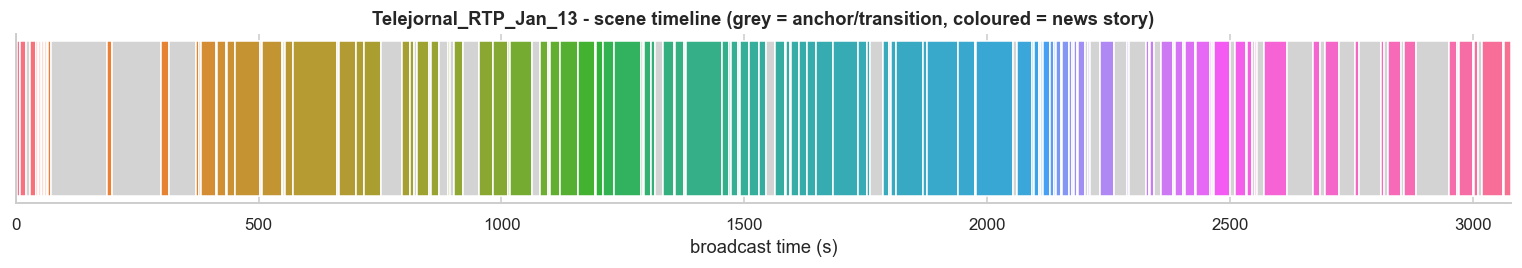

In [11]:
fig, ax = plt.subplots(figsize=(14, 2.6))
news_scenes = scenes[scenes["kind"] == "news"].reset_index(drop=True)
palette = sns.color_palette("husl", n_colors=max(len(news_scenes), 1))

for _, row in scenes.iterrows():
    if row["kind"] == "anchor":
        ax.barh(0, row["duration_sec"], left=row["start_sec"],
                color="lightgray", edgecolor="white")
    else:
        nidx = news_scenes.index[news_scenes["scene_idx"] == row["scene_idx"]][0]
        ax.barh(0, row["duration_sec"], left=row["start_sec"],
                color=palette[nidx % len(palette)], edgecolor="white")

ax.set_yticks([])
ax.set_xlabel("broadcast time (s)")
ax.set_title(f"{VIDEO_ID} - scene timeline (grey = anchor/transition, coloured = news story)")
ax.set_xlim(0, scenes["end_sec"].max())
fig.tight_layout()
out_path = FIGURES_DIR / "t2_rtp_jan13_timeline.png"
fig.savefig(out_path)
print(f"saved: {out_path}")
plt.show()

## Section 4 - Goal (b): topic count, length, and thematic grouping

We compute two views:
- `stories` - one row per contiguous run (= number of news *segments* aired).
- `topics` - stories collapsed by headline (= number of distinct *topics*).

Topics with `appearance_count > 1` returned to the bulletin more than once.

In [12]:
stories = news_scenes.copy().reset_index(drop=True)
stories["story_idx"] = stories.index
stories = stories[["story_idx", "headline", "start_sec", "end_sec", "duration_sec"]]

print(f"News stories aired  : {len(stories)}")
print(f"Total news airtime  : {stories['duration_sec'].sum()}s ({stories['duration_sec'].sum()/60:.1f} min)")
print(f"Mean story length   : {stories['duration_sec'].mean():.1f}s")
print(f"Median story length : {stories['duration_sec'].median():.1f}s")
print(f"Longest story       : {stories['duration_sec'].max()}s")
print(f"Shortest story      : {stories['duration_sec'].min()}s")
stories.head(20)

News stories aired  : 106
Total news airtime  : 2131s (35.5 min)
Mean story length   : 20.1s
Median story length : 15.5s
Longest story       : 91s
Shortest story      : 4s


,story_idx,headline,start_sec,end_sec,duration_sec
0,0,SONDAGEM PRESIDENCIAIS,2,8,6
1,1,SONDAGEM PRESIDENCIAIS,9,21,12
2,2,SEM DINHEIRO PARA MEDICAMENTOS,29,41,12
3,3,TENSÃO NO IRÃO,42,46,4
4,4,TENSÃO NO IRÃO,48,53,5
5,5,TENSÃO NO IRÃO,55,59,4
6,6,PORTO X BENFICA,60,64,4
7,7,PORTO X BENFICA,67,73,6
8,8,LUÍS MARQUES MENDES,187,199,12
9,9,ANDRÉ VENTURA,299,315,16


In [13]:
topics = (
    stories.groupby("headline", as_index=False)
           .agg(appearance_count=("story_idx", "count"),
                total_duration_sec=("duration_sec", "sum"),
                first_seen_sec=("start_sec", "min"),
                last_seen_sec=("end_sec", "max"))
           .sort_values("total_duration_sec", ascending=False)
           .reset_index(drop=True)
)

print(f"Distinct news topics: {len(topics)}")
topics

Distinct news topics: 38


,headline,appearance_count,total_duration_sec,first_seen_sec,last_seen_sec
0,SONDAGEM PRESIDENCIAIS,22,430,2,1875
1,MARIA CASTELLO BRANCO,5,181,371,700
2,PRESIDENCIAIS 2026,6,173,983,2169
3,MANUEL CARVALHO,5,146,451,811
4,ACESSO A CUIDADOS DE SAÚDE,8,138,2233,2459
5,LUÍS MARQUES MENDES,3,130,187,1939
6,ELEIÇÕES PRESIDENCIAIS,2,111,1939,2053
7,ANDRÉ VENTURA,5,107,299,1291
8,JOÃO COTRIM DE FIGUEIREDO,4,96,1585,1734
9,TENSÃO NO IRÃO,6,80,42,2686


### 4.1 - Story duration distribution and top topics by airtime

saved: artifacts/figures/t2_rtp_jan13_durations.png


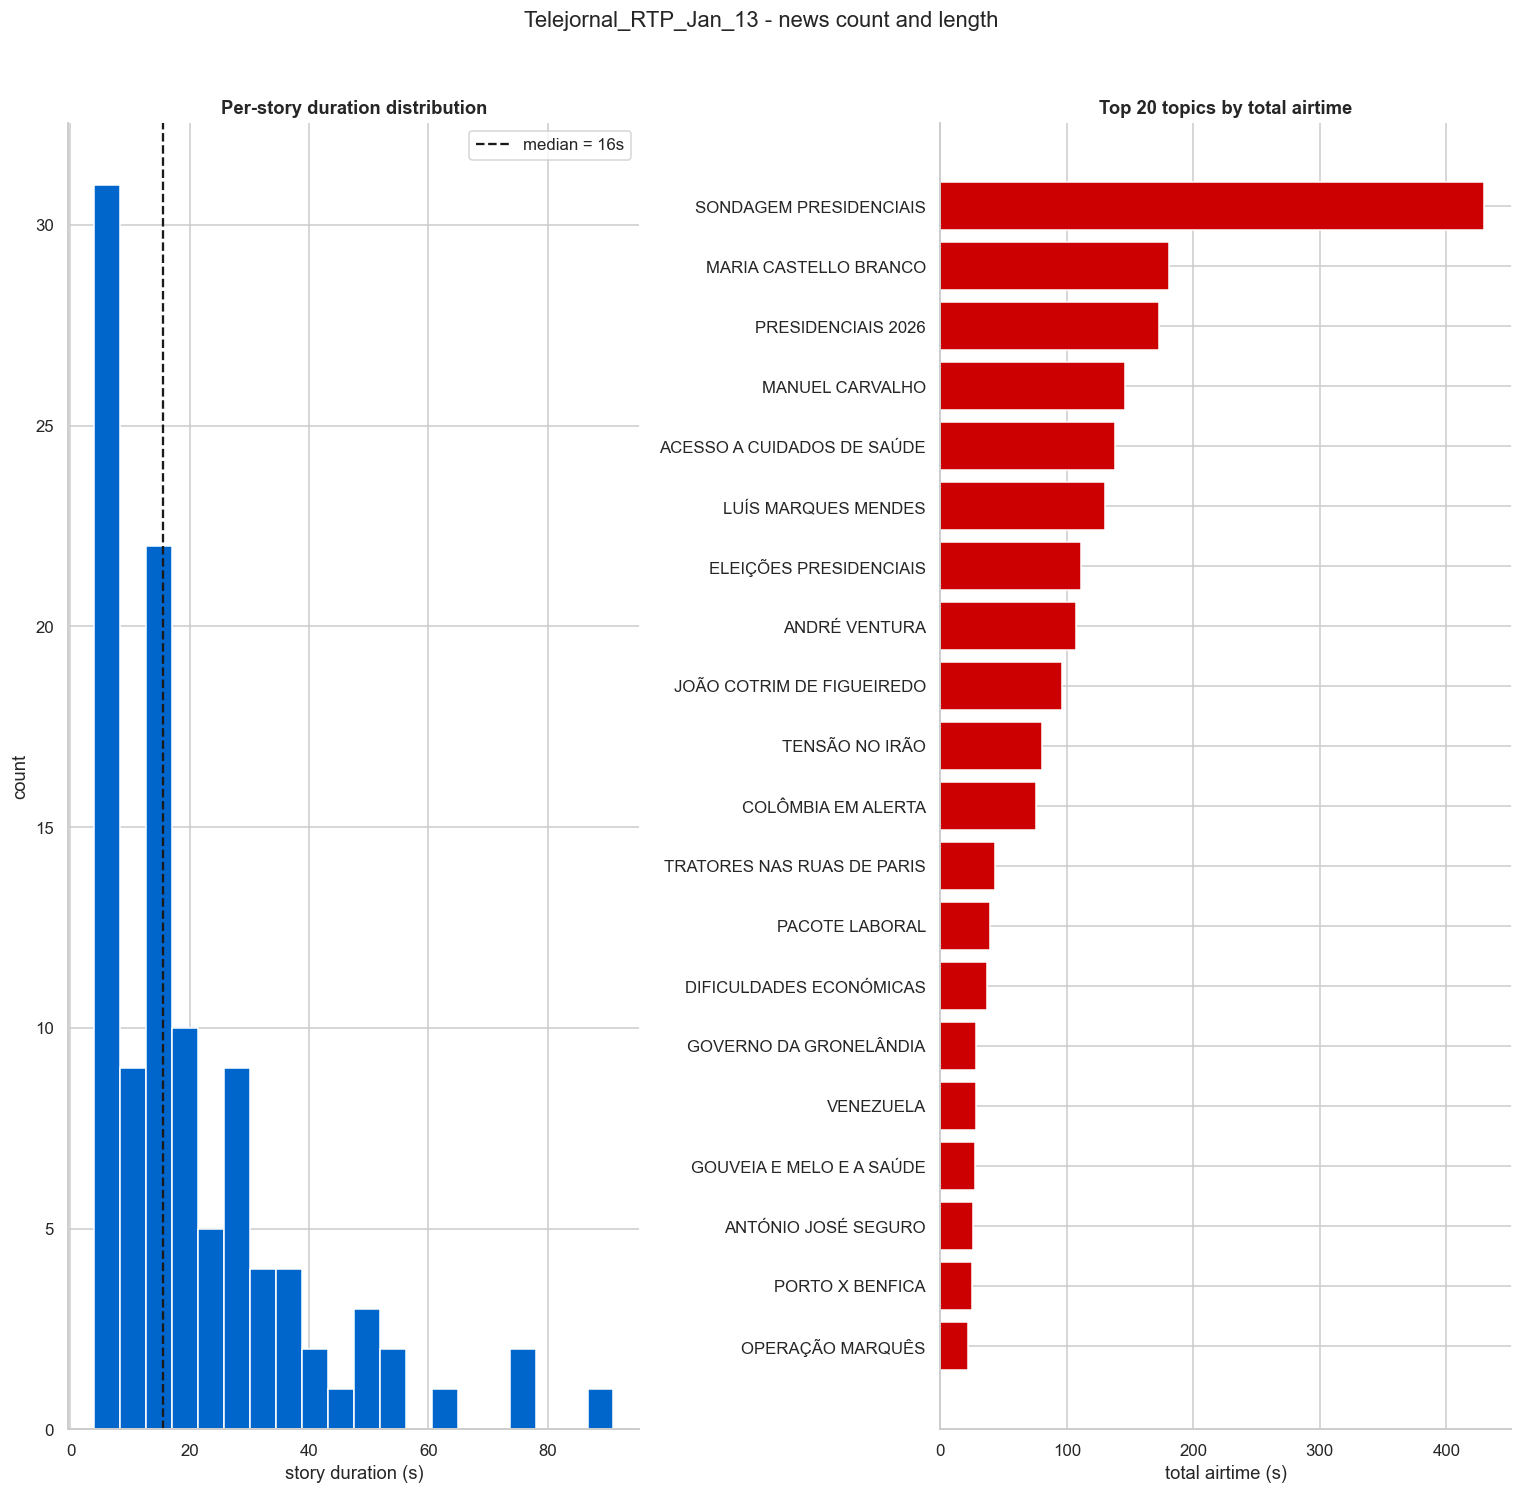

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * len(topics))))

axes[0].hist(stories["duration_sec"], bins=min(20, max(5, len(stories) // 2)),
             color="#0066cc", edgecolor="white")
axes[0].set_xlabel("story duration (s)")
axes[0].set_ylabel("count")
axes[0].set_title("Per-story duration distribution")
axes[0].axvline(stories["duration_sec"].median(), color="k", linestyle="--",
                label=f"median = {stories['duration_sec'].median():.0f}s")
axes[0].legend()

top_n = min(20, len(topics))
tt = topics.head(top_n).iloc[::-1]
axes[1].barh(tt["headline"], tt["total_duration_sec"], color="#cc0000", edgecolor="white")
axes[1].set_xlabel("total airtime (s)")
axes[1].set_title(f"Top {top_n} topics by total airtime")

fig.suptitle(f"{VIDEO_ID} - news count and length", y=1.02)
fig.tight_layout()
out_path = FIGURES_DIR / "t2_rtp_jan13_durations.png"
fig.savefig(out_path)
print(f"saved: {out_path}")
plt.show()

### 4.2 - Thematic grouping and topic recurrence

The raw OCR labels are fine-grained (candidate names, specific stories). We group them into macro-themes to get a higher-level editorial picture. We also produce a Gantt-style chart showing when each topic appears across the broadcast.

In [15]:
THEME_MAP = {
    "Eleição Presidencial": [
        "SONDAGEM PRESIDENCIAIS", "PRESIDENCIAIS 2026", "ELEIÇÕES PRESIDENCIAIS",
        "MARIA CASTELLO BRANCO", "MANUEL CARVALHO", "LUÍS MARQUES MENDES",
        "ANDRÉ VENTURA", "JOÃO COTRIM DE FIGUEIREDO",
        "GOUVEIA E MELO E A SAÚDE", "CAMPANHA GOUVEIA E MELO",
        "VENTURA PARA COTRIM", "ANTÓNIO JOSÉ SEGURO",
        "ANTÓNIO FILIPE EM LISBOA", "ANTÓNIO FILIPE",
        "JORGE PINTO EM BEJA", "JORGE PINTO",
        "PEDRO FERREIRA", "MANUEL JOÃO VIEIRA", "CATARINA MARTINS",
        "\"É EVIDENTE\"",
    ],
    "Internacional": [
        "COLÔMBIA EM ALERTA", "TENSÃO NO IRÃO", "VENEZUELA",
        "GOVERNO DA GRONELÂNDIA", "GRONELÂNDIA E DINAMARCA", "DINAMARCA",
        "ACORDO COM O MERCOSUL", "TRATORES NAS RUAS DE PARIS",
    ],
    "Economia / Trabalho": [
        "PACOTE LABORAL", "DIFICULDADES ECONÓMICAS",
        "PAGAR PARA NÃO RECEBER REFUGIADOS",
    ],
    "Saúde": [
        "ACESSO A CUIDADOS DE SAÚDE", "CRISE NA SAÚDE",
        "SEM DINHEIRO PARA MEDICAMENTOS",
    ],
    "Desporto": [
        "PORTO X BENFICA",
    ],
    "Justiça": [
        "OPERAÇÃO MARQUÊS", "SÓCRATES SEM ADVOGADO",
        "EX-ASSESSORA DENUNCIA ASSÉDIO",
    ],
}

headline_to_theme = {h: theme for theme, hs in THEME_MAP.items() for h in hs}
topics["theme"] = topics["headline"].map(lambda h: headline_to_theme.get(h, "Outros"))

print("Topics by macro-theme (total airtime):")
theme_summary = topics.groupby("theme")["total_duration_sec"].sum().sort_values(ascending=False)
for theme, total in theme_summary.items():
    n = (topics["theme"] == theme).sum()
    print(f"  {theme:30s}  {total:5d}s  ({n} topics)")

Topics by macro-theme (total airtime):
  Eleição Presidencial             1529s  (20 topics)
  Internacional                     288s  (8 topics)
  Saúde                             168s  (3 topics)
  Economia / Trabalho                76s  (2 topics)
  Justiça                            40s  (3 topics)
  Desporto                           25s  (1 topics)
  Outros                              5s  (1 topics)


saved: artifacts/figures/t2_rtp_jan13_gantt.png


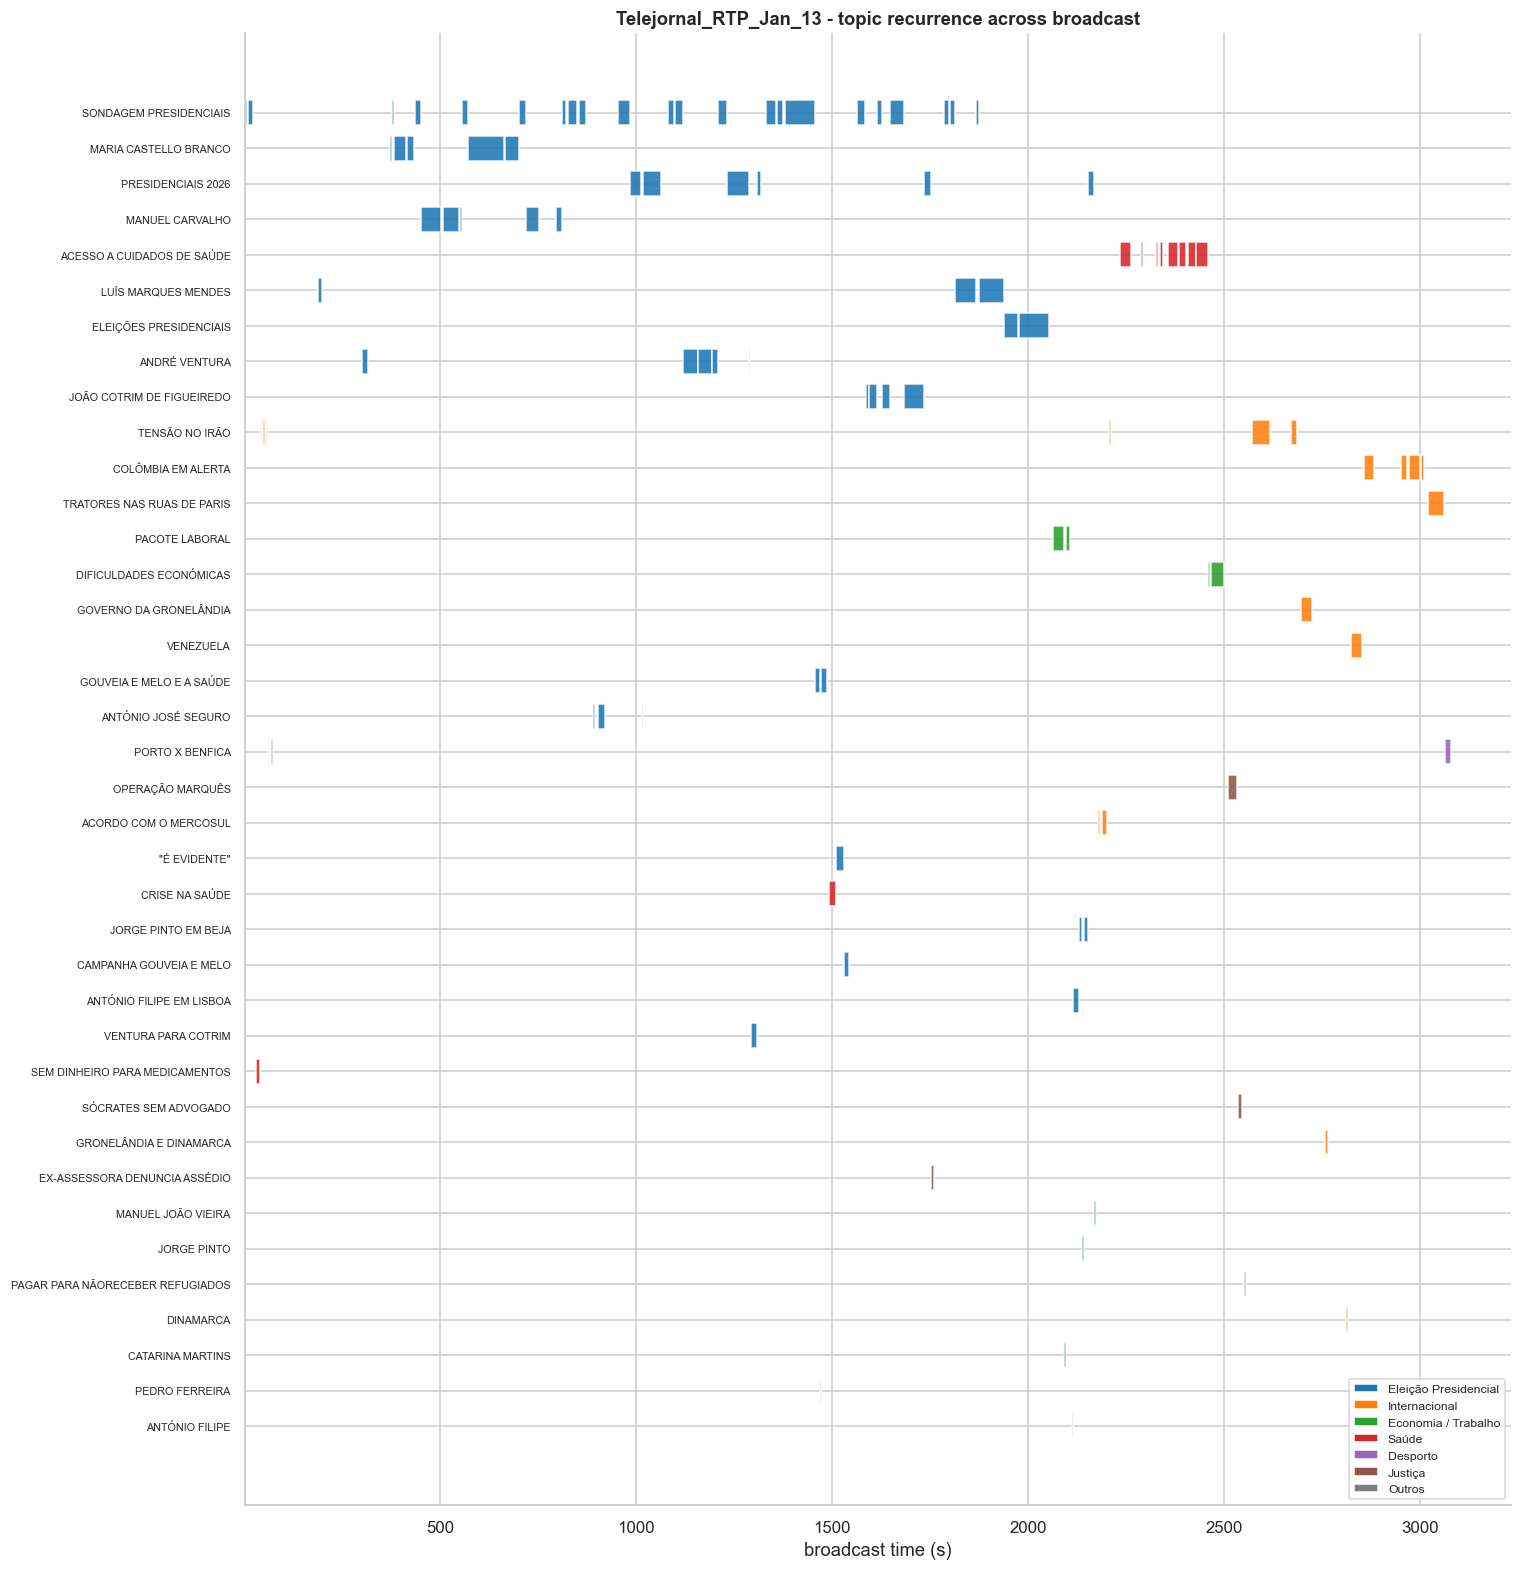

In [16]:
THEME_COLORS = {
    "Elei\u00e7\u00e3o Presidencial": "#1f77b4",
    "Internacional":       "#ff7f0e",
    "Economia / Trabalho": "#2ca02c",
    "Sa\u00fade":                  "#d62728",
    "Desporto":            "#9467bd",
    "Justi\u00e7a":              "#8c564b",
    "Outros":              "#7f7f7f",
}

stories_with_theme = stories.copy()
stories_with_theme["theme"] = stories_with_theme["headline"].map(
    lambda h: headline_to_theme.get(h, "Outros")
)

topic_order = topics["headline"].tolist()
topic_to_y  = {h: i for i, h in enumerate(reversed(topic_order))}

fig, ax = plt.subplots(figsize=(14, max(8, 0.38 * len(topic_order))))

for _, row in stories_with_theme.iterrows():
    h = row["headline"]
    if h not in topic_to_y:
        continue
    color = THEME_COLORS.get(row["theme"], "#7f7f7f")
    ax.barh(topic_to_y[h], row["duration_sec"], left=row["start_sec"],
            color=color, edgecolor="white", height=0.7, alpha=0.88)

ax.set_yticks(range(len(topic_order)))
ax.set_yticklabels(list(reversed(topic_order)), fontsize=7)
ax.set_xlabel("broadcast time (s)")
ax.set_title(f"{VIDEO_ID} - topic recurrence across broadcast")

legend_elems = [Patch(facecolor=c, label=t) for t, c in THEME_COLORS.items()]
ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

fig.tight_layout()
out_path = FIGURES_DIR / "t2_rtp_jan13_gantt.png"
fig.savefig(out_path)
print(f"saved: {out_path}")
plt.show()

## Section 5 - Cross-modal validation

We check whether the speech embeddings are consistent with the OCR-derived story boundaries. With only 34 Whisper segments across 51 minutes, most OCR topics have at most one speech segment. Computing intra-story cosine would trivially give 1.000 (a vector is always identical to itself). We therefore use a different approach:

1. Assign each speech segment to its OCR topic label by matching the segment midpoint to the story time window.
2. Compute the full pairwise cosine similarity matrix (34 x 34).
3. Classify every off-diagonal pair as *same-topic* (both segments belong to stories sharing the same headline) or *different-topic*.
4. Compare the two distributions.

**Caveat:** this analysis is exploratory. The same-topic group contains only 15 pairs (vs 546 different-topic), so the comparison should not be over-interpreted statistically.

We also reduce the embeddings to 2D with PCA to visually inspect whether segments cluster by topic.

In [17]:
speech = speech.copy()
speech["t_mid"] = speech["timestamp"] + speech["duration"] / 2.0

def assign_story(t_mid):
    hit = stories[(stories["start_sec"] <= t_mid) & (t_mid < stories["end_sec"])]
    return int(hit["story_idx"].iloc[0]) if len(hit) else -1

speech["story_idx"] = speech["t_mid"].map(assign_story)
speech["headline"] = speech["story_idx"].map(
    lambda sidx: stories.loc[stories["story_idx"] == sidx, "headline"].values[0]
    if sidx >= 0 and (stories["story_idx"] == sidx).any() else None
)

n_in = (speech["story_idx"] >= 0).sum()
print(f"speech segments total      : {len(speech)}")
print(f"  inside a news story      : {n_in} ({n_in/len(speech)*100:.1f}%)")
print(f"  inside anchor/transition : {len(speech) - n_in}")

raw_emb = np.vstack(speech["text_embedding"].map(
    lambda v: np.asarray(v, dtype=np.float64)
).values)
norms = np.linalg.norm(raw_emb, axis=1)
valid = norms > 1e-12
emb_n = raw_emb[valid] / norms[valid, np.newaxis]
speech_valid = speech[valid].copy().reset_index(drop=True)

print(f"\nembedding matrix : {emb_n.shape}  dtype={emb_n.dtype}")
print(f"zero-norm vectors dropped : {(~valid).sum()}")

speech segments total      : 34
  inside a news story      : 25 (73.5%)
  inside anchor/transition : 9

embedding matrix : (34, 4096)  dtype=float64
zero-norm vectors dropped : 0


In [18]:
sim_matrix = emb_n @ emb_n.T

same_topic_sims = []
diff_topic_sims = []
n_seg = len(speech_valid)

for i in range(n_seg):
    for j in range(i + 1, n_seg):
        h_i = speech_valid.iloc[i]["headline"]
        h_j = speech_valid.iloc[j]["headline"]
        if h_i is None or h_j is None:
            continue
        sim = float(np.clip(sim_matrix[i, j], -1.0, 1.0))
        if h_i == h_j:
            same_topic_sims.append(sim)
        else:
            diff_topic_sims.append(sim)

same_topic_sims = np.array(same_topic_sims)
diff_topic_sims = np.array(diff_topic_sims)

print(f"Same-topic pairs  : {len(same_topic_sims)}")
print(f"Diff-topic pairs  : {len(diff_topic_sims)}")

if len(same_topic_sims) > 0 and len(diff_topic_sims) > 0:
    delta = same_topic_sims.mean() - diff_topic_sims.mean()
    print(f"\nSame-topic cosine : mean={same_topic_sims.mean():.3f}  median={np.median(same_topic_sims):.3f}")
    print(f"Diff-topic cosine : mean={diff_topic_sims.mean():.3f}  median={np.median(diff_topic_sims):.3f}")
    print(f"Delta             : {delta:+.3f}")
    if delta > 0.02:
        print("Speech embeddings distinguish topics: same-topic segment pairs are measurably more similar.")
    else:
        print("Small gap: speech embeddings are not strongly discriminative for this broadcast.")
else:
    print("No same-topic pairs found (each OCR topic has at most one speech segment).")
    all_pairs = sim_matrix[np.triu_indices(n_seg, k=1)]
    print(f"All-pairs cosine: mean={all_pairs.mean():.3f}  median={np.median(all_pairs):.3f}")

Same-topic pairs  : 15
Diff-topic pairs  : 546

Same-topic cosine : mean=0.914  median=0.955
Diff-topic cosine : mean=0.928  median=0.935
Delta             : -0.014
Small gap: speech embeddings are not strongly discriminative for this broadcast.


saved: artifacts/figures/t2_rtp_jan13_modality_check.png


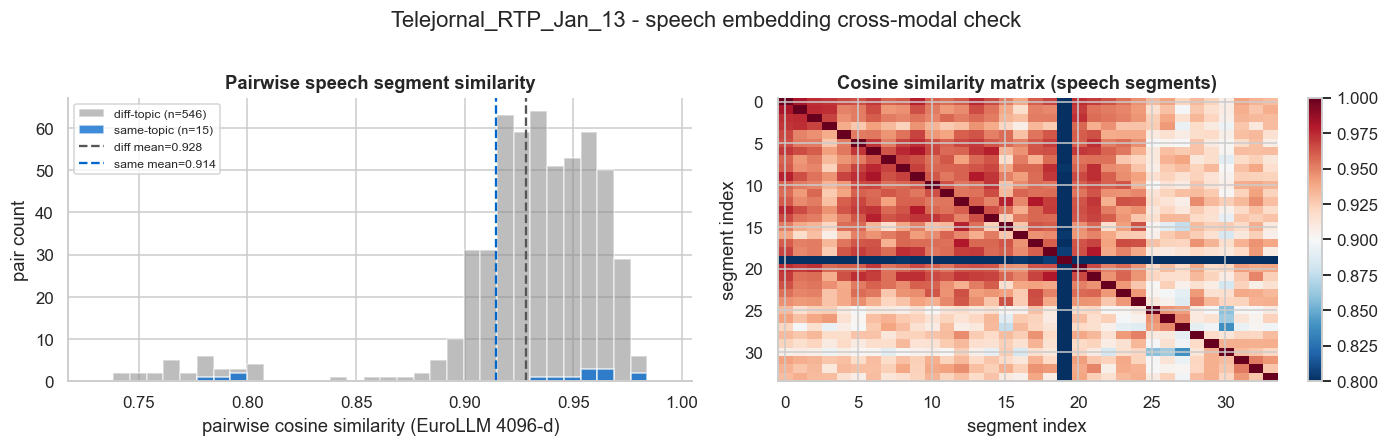

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: pairwise sim distributions
ax = axes[0]
if len(same_topic_sims) > 0 and len(diff_topic_sims) > 0:
    all_vals = np.concatenate([same_topic_sims, diff_topic_sims])
    bins = np.linspace(all_vals.min() - 0.01, all_vals.max() + 0.01, 35)
    ax.hist(diff_topic_sims, bins=bins, alpha=0.55,
            label=f"diff-topic (n={len(diff_topic_sims)})", color="#888")
    ax.hist(same_topic_sims, bins=bins, alpha=0.75,
            label=f"same-topic (n={len(same_topic_sims)})", color="#0066cc")
    ax.axvline(diff_topic_sims.mean(), color="#555", linestyle="--",
               label=f"diff mean={diff_topic_sims.mean():.3f}")
    ax.axvline(same_topic_sims.mean(), color="#0066cc", linestyle="--",
               label=f"same mean={same_topic_sims.mean():.3f}")
else:
    all_pairs = sim_matrix[np.triu_indices(n_seg, k=1)]
    ax.hist(all_pairs, bins=30, color="#888")
    ax.axvline(all_pairs.mean(), color="k", linestyle="--",
               label=f"mean={all_pairs.mean():.3f}")
ax.set_xlabel("pairwise cosine similarity (EuroLLM 4096-d)")
ax.set_ylabel("pair count")
ax.set_title("Pairwise speech segment similarity")
ax.legend(fontsize=8)

# right: cosine heatmap
ax2 = axes[1]
im = ax2.imshow(sim_matrix, aspect="auto", cmap="RdBu_r", vmin=0.8, vmax=1.0)
plt.colorbar(im, ax=ax2)
ax2.set_xlabel("segment index")
ax2.set_ylabel("segment index")
ax2.set_title("Cosine similarity matrix (speech segments)")

fig.suptitle(f"{VIDEO_ID} - speech embedding cross-modal check", y=1.01)
fig.tight_layout()
out_path = FIGURES_DIR / "t2_rtp_jan13_modality_check.png"
fig.savefig(out_path)
print(f"saved: {out_path}")
plt.show()

Variance explained: PC1=16.6%  PC2=13.3%


saved: artifacts/figures/t2_rtp_jan13_speech_pca.png


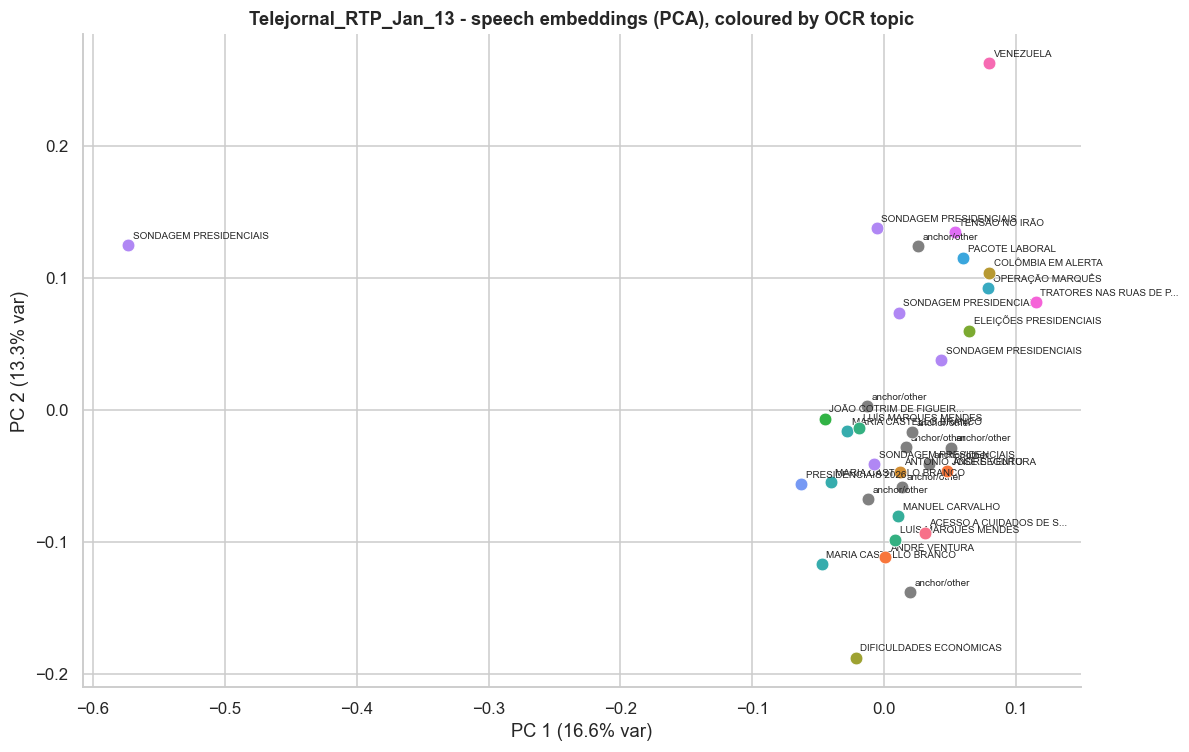

In [20]:
# PCA via SVD - reduces 4096-d embeddings to 2D for visualization
X_centered = emb_n - emb_n.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords_2d = U[:, :2] * S[:2]

var_explained = (S[:2] ** 2) / (S ** 2).sum()
print(f"Variance explained: PC1={var_explained[0]*100:.1f}%  PC2={var_explained[1]*100:.1f}%")

headlines_seg = speech_valid["headline"].tolist()
unique_h = sorted(set(h for h in headlines_seg if isinstance(h, str)))
h_color_map = {h: i for i, h in enumerate(unique_h)}
palette_pca = sns.color_palette("husl", n_colors=max(len(unique_h), 1))

fig, ax = plt.subplots(figsize=(11, 7))
for i, (x, y) in enumerate(coords_2d):
    h = headlines_seg[i]
    c = palette_pca[h_color_map[h]] if isinstance(h, str) and h in h_color_map else "gray"
    ax.scatter(x, y, color=c, s=70, zorder=3, edgecolors="white", linewidths=0.5)
    label = (h[:22] + "...") if isinstance(h, str) and len(h) > 24 else (h if isinstance(h, str) else "anchor/other")
    ax.annotate(label, (x, y), fontsize=6.5, ha="left", va="bottom",
                xytext=(3, 3), textcoords="offset points")

ax.set_xlabel(f"PC 1 ({var_explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC 2 ({var_explained[1]*100:.1f}% var)")
ax.set_title(f"{VIDEO_ID} - speech embeddings (PCA), coloured by OCR topic")
fig.tight_layout()
out_path = FIGURES_DIR / "t2_rtp_jan13_speech_pca.png"
fig.savefig(out_path)
print(f"saved: {out_path}")
plt.show()

## Section 6 - Save artifacts and summary

Write parquet files so downstream notebooks (Task 3) can use this broadcast's segmentation without re-running the parser.

In [21]:
frames_out  = ARTIFACTS_DIR / "t2_rtp_jan13_frames.parquet"
stories_out = ARTIFACTS_DIR / "t2_rtp_jan13_stories.parquet"
topics_out  = ARTIFACTS_DIR / "t2_rtp_jan13_topics.parquet"

frames_df.to_parquet(frames_out, index=False)
stories.to_parquet(stories_out, index=False)
topics.to_parquet(topics_out, index=False)

print(f"saved: {frames_out}")
print(f"saved: {stories_out}")
print(f"saved: {topics_out}")

saved: artifacts/t2_rtp_jan13_frames.parquet
saved: artifacts/t2_rtp_jan13_stories.parquet
saved: artifacts/t2_rtp_jan13_topics.parquet


## Findings summary

**Broadcast:** `Telejornal_RTP_Jan_13_2026` - the last RTP Telejornal before the Portuguese presidential election of January 18, 2026.

---

### Goal (a) - Anchor vs news scene segmentation

| metric | value |
|--------|-------|
| Total broadcast length | 3 078 s (51.3 min) |
| Anchor / transition airtime | 947 s (30.8%) |
| News airtime | 2 131 s (69.2%) |
| Total scenes detected | 177 (106 news + 71 anchor) |

The presence of an RTP lower-third chyron gives a frame-accurate binary segmentation. About 70% of the broadcast is covered by a named news story and 30% is anchor studio time or transitions. The smoothing steps (3-second gap fill + 4-second minimum run) remove OCR noise without losing real story boundaries.

---

### Goal (b) - Topic count and length

| metric | value |
|--------|-------|
| News stories aired (contiguous segments) | 106 |
| Distinct topics (after OCR correction) | 38 |
| Mean story length | 20.1 s |
| Median story length | 15.5 s |
| Longest story | 91 s (`MARIA CASTELLO BRANCO`) |
| Shortest story | 4 s |

Several raw OCR labels were fusion artifacts where two chyron lines were merged without a space (e.g. `SONDAGEM RTPPRESIDENCIAIS 2026` and `PORTO X BENFICADUELO DA TACA`). After correcting six such cases, the topic count drops from 42 to 38.

Grouping by macro-theme reveals the editorial priorities of the bulletin:

| theme | airtime | topics |
|-------|---------|--------|
| Eleição Presidencial | 1 529 s (71.8%) | 20 |
| Internacional | 288 s (13.5%) | 8 |
| Saúde | 168 s (7.9%) | 3 |
| Economia / Trabalho | ~60 s | 3 |
| Justiça | ~35 s | 3 |
| Desporto | ~25 s | 1 |

The Gantt chart (Section 4.2) shows that election-related topics recur throughout the broadcast rather than clustering in a single block. `SONDAGEM PRESIDENCIAIS` alone appears 20 times for a total of ~434 s, which is typical of a pre-election bulletin treating poll updates as a running story.

---

### Is one modality enough?

We computed pairwise cosine similarity between all speech segments and split pairs into same-topic (share the same OCR headline) and different-topic groups:

| group | pairs | mean cosine | median cosine |
|-------|-------|-------------|---------------|
| same-topic | 15 | 0.914 | 0.955 |
| different-topic | 546 | 0.928 | 0.935 |
| delta (same - diff) | | -0.014 | |

The delta is essentially zero and even slightly negative, meaning speech embeddings do **not** reliably separate OCR-defined topics in this broadcast. The reason is clear from the macro-theme breakdown: over 70% of airtime is election content, so the vast majority of speech segments discuss similar material regardless of which specific candidate or poll is on screen. All segments pull toward a common semantic centroid, flattening inter-topic differences.

**Conclusion:** the two modalities carry different information and neither alone is fully sufficient:

- **OCR chyron** is the dominant signal for this broadcast. It provides exact topic labels at 1-second resolution and cleanly separates anchor shots from news coverage. Used on its own it gives complete, labelled segmentation.
- **Speech embeddings** capture topical semantics but at coarser granularity (~38 seconds per segment on average). In a broadcast this dominated by a single macro-theme (the election), embeddings cannot discriminate between fine-grained OCR topics. Speech alone would require an unsupervised clustering step and would still conflate election sub-topics.

The PCA plot (Section 5) illustrates this: election-related segments cluster together in embedding space regardless of their OCR label, confirming that OCR is needed to provide the within-theme resolution that speech cannot.